# Plotting Utilities Notebook

This notebook is the notebook version of `utils.py`, adapted to this repo layout. It reads Lotka--Volterra result `.npz` files from the project root, renders figures inline, and saves the main panel figure to `figures/lv_summary.pdf`.


In [ ]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

ROOT = Path.cwd()
RESULTS_DIR = ROOT
FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
OUTPUT_FIGURE = FIGURES_DIR / "lv_summary.pdf"

plt.rcParams['axes.grid'] = True
plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath, amsfonts, mathrsfs, amssymb}')

SUMMARY_FIGSIZE = (30, 8)
FIGSIZE = (6, 4)
DPI = 100
TITLE_SIZE = 24
LABEL_SIZE = 32
TICK_SIZE = 24
LEGEND_SIZE = 32
MARKER_SIZE = 10
COMPARISON_SCATTER_SIZE = 28
LINE_WIDTH = 2.0
TITLE_PAD = 8
FOUR_PANEL_LEGEND_SIZE = 32
COLORS = {
        "clean_sgd_1": "#1b9e77",
        "clean_pgd_1": "#d95f02",
        "clean_sgd_2": "#0f6f54",
        "clean_pgd_2": "#D62728",
        "cor_10": "#E78AC3",
        "cor_35": "#7B3294",
        "truth": "#f4b400",
    }

BASE_PLOT_RC = {
    "axes.grid": True,
    "font.family": "DejaVu Serif",
    "font.serif": ["Times New Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath, amsfonts, mathrsfs, amssymb}",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "legend.fontsize": LEGEND_SIZE,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "lines.linewidth": LINE_WIDTH,
    "lines.markersize": MARKER_SIZE,
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
}
LOCAL_PLOT_RC = dict(BASE_PLOT_RC)
plt.rcParams.update(BASE_PLOT_RC)
ROOT, RESULTS_DIR, OUTPUT_FIGURE


(PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL'),
 PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL'),
 PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/figures/lv_summary.pdf'))

In [62]:
def _load_npz_dict(npz_path):
    npz_path = Path(npz_path)
    with np.load(npz_path) as data:
        return {key: data[key] for key in data.files}


def _save_figure(fig, output_path=None, **savefig_kwargs):
    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, **savefig_kwargs)
    return fig


def _lv_plot_branch(ax, hist, color, markevery):
    ax.plot(hist[:, 0], hist[:, 1], color=color, marker="o", markevery=markevery, markersize=3.0)
    ax.scatter(hist[0, 0], hist[0, 1], color="white", edgecolors=color, linewidths=1.5, s=52, zorder=4)
    ax.scatter(hist[-1, 0], hist[-1, 1], color=color, marker="s", s=48, zorder=5)


def _lv_draw_theta12_trajectory(ax, npz_paths, show_true=True):
    path_colors = [
        (COLORS["clean_sgd_1"], COLORS["clean_pgd_1"]),
        (COLORS["clean_sgd_2"], COLORS["clean_pgd_2"]),
    ]

    theta_true = None
    for idx, npz_path in enumerate(npz_paths):
        data = _load_npz_dict(npz_path)
        sgd = np.asarray(data["sgd_theta_history_mean"], dtype=float)[:, :2]
        pgd = np.asarray(data["pgd_theta_history_mean"], dtype=float)[:, :2]
        theta_true = np.asarray(data["theta_true"], dtype=float)
        sgd_color, pgd_color = path_colors[min(idx, len(path_colors) - 1)]
        _lv_plot_branch(ax, sgd, sgd_color, max(1, len(sgd) // 22))
        _lv_plot_branch(ax, pgd, pgd_color, max(1, len(pgd) // 22))

    if show_true and theta_true is not None:
        ax.scatter(theta_true[0], theta_true[1], marker="*", s=260, color=COLORS["truth"], zorder=6)

    ax.set_xlabel(r"Parameter 1 ($\theta_1$)")
    ax.set_ylabel(r"Parameter 2 ($\theta_2$)")
    ax.grid(True, alpha=0.24, linewidth=0.8)


def make_lv_theta_trajectory_plot(npz_paths, output_path=None, show_true=True):
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(5.2, 4.9), dpi=150)
        _lv_draw_theta12_trajectory(ax, npz_paths, show_true=show_true)
        fig.tight_layout()
        return _save_figure(fig, output_path)


def _lv_draw_history_panel(
    ax,
    bundles,
    param_idx,
    ylabel,
    true_theta,
    show_xlabel=True,
    se_scale=1.96,
    true_only=True,
):
    for data, color_sgd, color_pgd, ls_sgd, ls_pgd in bundles:
        sgd_steps = np.asarray(data["sgd_history_steps"], dtype=float) + 1.0
        pgd_steps = np.asarray(data["pgd_history_steps"], dtype=float) + 1.0
        sgd_hist = np.asarray(data["sgd_theta_histories"], dtype=float)[:, :, param_idx]
        pgd_hist = np.asarray(data["pgd_theta_histories"], dtype=float)[:, :, param_idx]

        sgd_mean = sgd_hist.mean(axis=0)
        pgd_mean = pgd_hist.mean(axis=0)
        sgd_se = sgd_hist.std(axis=0, ddof=0) / np.sqrt(max(sgd_hist.shape[0], 1))
        pgd_se = pgd_hist.std(axis=0, ddof=0) / np.sqrt(max(pgd_hist.shape[0], 1))

        ax.plot(sgd_steps, sgd_mean, color=color_sgd, linestyle=ls_sgd, linewidth=2.0)
        ax.fill_between(
            sgd_steps,
            sgd_mean - se_scale * sgd_se,
            sgd_mean + se_scale * sgd_se,
            color=color_sgd,
            alpha=0.12,
        )
        ax.plot(pgd_steps, pgd_mean, color=color_pgd, linestyle=ls_pgd, linewidth=2.0)
        ax.fill_between(
            pgd_steps,
            pgd_mean - se_scale * pgd_se,
            pgd_mean + se_scale * pgd_se,
            color=color_pgd,
            alpha=0.12,
        )

    if true_only:
        ax.axhline(float(true_theta[param_idx]), color="0.35", linestyle="--", linewidth=1.2)

    ax.set_xscale("log")
    ax.set_xlabel("Iteration" if show_xlabel else "")
    ax.set_ylabel(ylabel)
    ax.grid(True, which="major", alpha=0.28, linewidth=0.8)


def make_lv_param_history_plot_from_npz(
    npz_path,
    param_idx,
    output_path=None,
    se_scale=1.96,
    solid_for_both=True,
    true_only=True,
    show_xlabel=True,
):
    data = _load_npz_dict(npz_path)
    bundles = [
        (
            data,
            COLORS["clean_sgd_1"],
            COLORS["clean_pgd_1"],
            "-" if solid_for_both else "--",
            "-",
        )
    ]
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(7.1, 4.8), dpi=150)
        _lv_draw_history_panel(
            ax,
            bundles,
            param_idx=param_idx,
            ylabel=rf"$\theta_{param_idx + 1}$",
            true_theta=np.asarray(data["theta_true"], dtype=float),
            show_xlabel=show_xlabel,
            se_scale=se_scale,
            true_only=true_only,
        )
        fig.tight_layout()
        return _save_figure(fig, output_path)


def make_lv_dual_init_history_plot(
    npz_paths,
    param_idx,
    output_path=None,
    figsize=(6, 2),
    dpi=100,
    se_scale=1.96,
):
    bundles = []
    for idx, npz_path in enumerate(npz_paths):
        data = _load_npz_dict(npz_path)
        if idx == 0:
            bundles.append((data, COLORS["clean_sgd_1"], COLORS["clean_pgd_1"], "-", "-"))
        else:
            bundles.append((data, COLORS["clean_sgd_2"], COLORS["clean_pgd_2"], "-", "-"))

    true_theta = np.asarray(bundles[0][0]["theta_true"], dtype=float)
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
        _lv_draw_history_panel(
            ax,
            bundles,
            param_idx=param_idx,
            ylabel=rf"$\theta_{param_idx + 1}$",
            true_theta=true_theta,
            show_xlabel=True,
            se_scale=se_scale,
            true_only=True,
        )
        fig.tight_layout()
        return _save_figure(fig, output_path)


def make_lv_corruption_history_plot(
    npz_paths,
    param_idx,
    output_path=None,
    figsize=(6, 2),
    dpi=100,
    se_scale=1.96,
):
    bundles = []
    for idx, npz_path in enumerate(npz_paths):
        data = _load_npz_dict(npz_path)
        color = COLORS["cor_10"] if idx == 0 else COLORS["cor_35"]
        bundles.append((data, color, color, "--", "-"))

    true_theta = np.asarray(bundles[0][0]["theta_true"], dtype=float)
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
        _lv_draw_history_panel(
            ax,
            bundles,
            param_idx=param_idx,
            ylabel=rf"$\theta_{param_idx + 1}$",
            true_theta=true_theta,
            show_xlabel=True,
            se_scale=se_scale,
            true_only=True,
        )
        fig.tight_layout()
        return _save_figure(fig, output_path)


def make_lv_five_panel_summary(
    clean_npz_paths,
    corruption_npz_paths,
    output_path=None,
    figsize=(24, 5),
    dpi=100,
    se_scale=1.96,
):
    clean_data = [_load_npz_dict(path) for path in clean_npz_paths]
    cor_data = [_load_npz_dict(path) for path in corruption_npz_paths]
    theta_true = np.asarray(clean_data[0]["theta_true"], dtype=float)

    with plt.rc_context(LOCAL_PLOT_RC):
        fig = plt.figure(figsize=figsize, dpi=dpi)
        gs = fig.add_gridspec(2, 3, width_ratios=[1.0, 1.05, 1.05], wspace=0.42, hspace=0.38)
        ax_traj = fig.add_subplot(gs[:, 0])
        ax_clean_1 = fig.add_subplot(gs[0, 1])
        ax_clean_2 = fig.add_subplot(gs[1, 1])
        ax_cor_1 = fig.add_subplot(gs[0, 2])
        ax_cor_2 = fig.add_subplot(gs[1, 2])

        _lv_draw_theta12_trajectory(ax_traj, clean_npz_paths, show_true=True)

        clean_bundles = [
            (clean_data[0], COLORS["clean_sgd_1"], COLORS["clean_pgd_1"], "-", "-"),
            (clean_data[1], COLORS["clean_sgd_2"], COLORS["clean_pgd_2"], "-", "-"),
        ]
        cor_bundles = [
            (cor_data[0], COLORS["cor_10"], COLORS["cor_10"], "--", "-"),
            (cor_data[1], COLORS["cor_35"], COLORS["cor_35"], "--", "-"),
        ]

        _lv_draw_history_panel(ax_clean_1, clean_bundles, 0, r"$\theta_1$", theta_true, show_xlabel=False, se_scale=se_scale)
        _lv_draw_history_panel(ax_clean_2, clean_bundles, 1, r"$\theta_2$", theta_true, show_xlabel=True, se_scale=se_scale)
        _lv_draw_history_panel(ax_cor_1, cor_bundles, 0, r"$\theta_1$", theta_true, show_xlabel=False, se_scale=se_scale)
        _lv_draw_history_panel(ax_cor_2, cor_bundles, 1, r"$\theta_2$", theta_true, show_xlabel=True, se_scale=se_scale)

        left_handles = [
            Line2D([0], [0], color=COLORS["clean_sgd_1"], linestyle="-", linewidth=2.2, label="GD"),
            Line2D([0], [0], color=COLORS["clean_pgd_1"], linestyle="-", linewidth=2.2, label="PGD"),
        ]
        right_handles = [
            Line2D([0], [0], color="black", linestyle="--", linewidth=2.2, label="GD (corrupted)"),
            Line2D([0], [0], color="black", linestyle="-", linewidth=2.2, label="PGD (corrupted)"),
            Line2D([0], [0], color=COLORS["cor_10"], linestyle="-", linewidth=2.2, label="10\%"),
            Line2D([0], [0], color=COLORS["cor_35"], linestyle="-", linewidth=2.2, label="35\%"),
        ]

        fig.legend(
            left_handles,
            [h.get_label() for h in left_handles],
            loc="upper left",
            bbox_to_anchor=(0.18, 1.03),
            ncol=2,
            frameon=False,
            fontsize=32,
            handlelength=2.2,
            columnspacing=1.4,
            handletextpad=0.6,
        )
        fig.legend(
            right_handles,
            [h.get_label() for h in right_handles],
            loc="upper right",
            bbox_to_anchor=(0.93, 1.03),
            ncol=4,
            frameon=False,
            fontsize=32,
            handlelength=2.2,
            columnspacing=1.2,
            handletextpad=0.6,
        )

        fig.tight_layout(rect=(0, 0, 1, 0.92))
        return _save_figure(fig, output_path, bbox_inches="tight")


## Local file setup

These defaults match the files that already exist in this repo. The iteration-history and `lhs/rhs` inputs are optional because they are not currently present in this workspace.

In [63]:
clean_npz_paths = [
    RESULTS_DIR / "lotka_volterra_results_90_90.npz",
    RESULTS_DIR / "lotka_volterra_results_50_60.npz",
]
corruption_npz_paths = [
    RESULTS_DIR / "lotka_volterra_results_60_60_10c.npz",
    RESULTS_DIR / "lotka_volterra_results_60_60_35c.npz",
]

{
    "clean_npz_paths": clean_npz_paths,
    "corruption_npz_paths": corruption_npz_paths,
}


{'clean_npz_paths': [PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/lotka_volterra_results_90_90.npz'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/lotka_volterra_results_50_60.npz')],
 'corruption_npz_paths': [PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/lotka_volterra_results_60_60_10c.npz'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/lotka_volterra_results_60_60_35c.npz')]}

In [64]:
available_inputs = {
    "clean_npz_paths": [path.exists() for path in clean_npz_paths],
    "corruption_npz_paths": [path.exists() for path in corruption_npz_paths],
}
available_inputs


{'clean_npz_paths': [True, True], 'corruption_npz_paths': [True, True]}

/var/folders/w6/g5h90fqj0lb6gbnsvjgzt5bw0000gn/T/ipykernel_16994/532031587.py:272: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.92))


Saved figure to /Users/sophiakang/Documents/GitHub/MDF_AL/figures/lv_summary.pdf


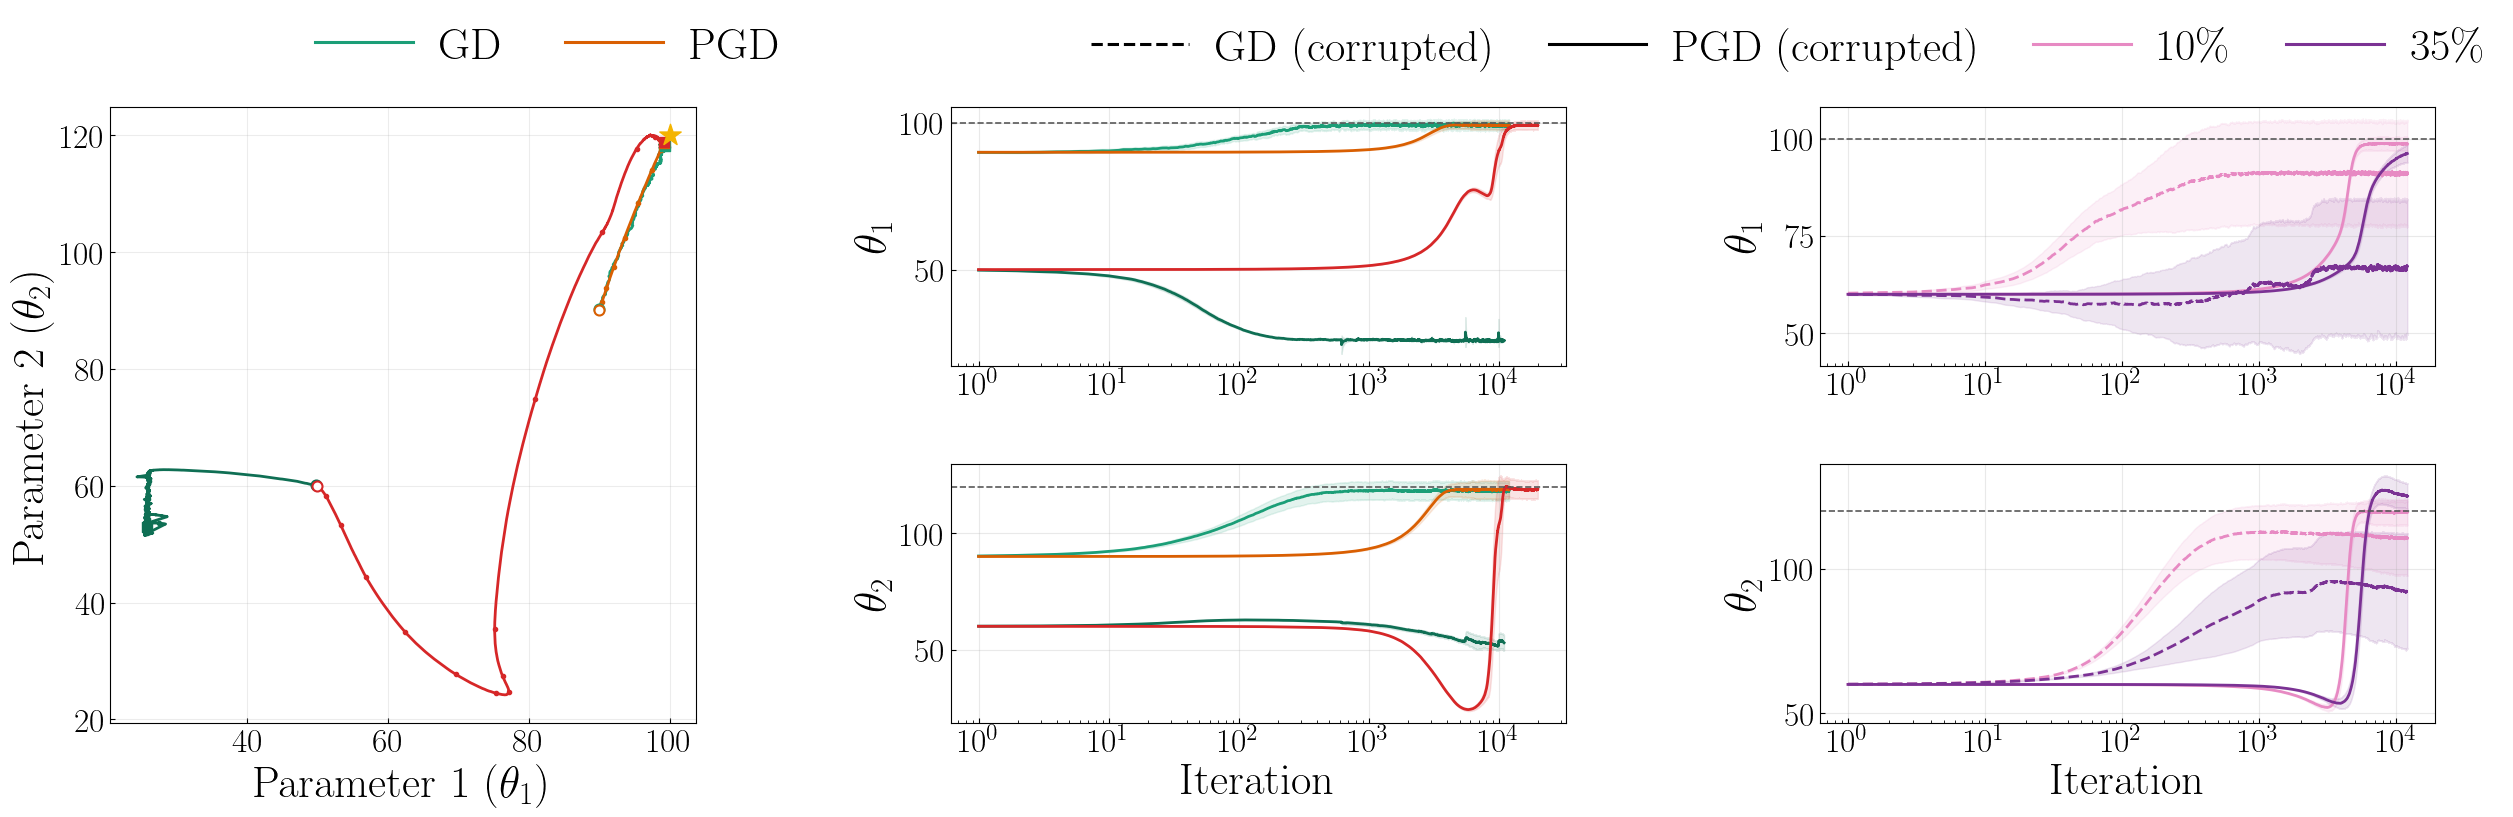

In [65]:
required_inputs = [*clean_npz_paths, *corruption_npz_paths]
missing_inputs = [path for path in required_inputs if not path.exists()]

if not missing_inputs:
    fig = make_lv_five_panel_summary(
        clean_npz_paths=clean_npz_paths,
        corruption_npz_paths=corruption_npz_paths,
        output_path=None,
        figsize=SUMMARY_FIGSIZE,
        dpi=DPI,
        se_scale=1.96,
    )
    fig.savefig(OUTPUT_FIGURE, bbox_inches="tight")
    print(f"Saved figure to {OUTPUT_FIGURE}")
    display(fig)
else:
    print(
        f"Figure not rendered because {len(missing_inputs)} source input(s) are missing: "
        + ", ".join(str(path) for path in missing_inputs)
    )


In [66]:
# Figures render inline in the previous cell and are also saved to OUTPUT_FIGURE.
